In [1]:
import sys
sys.path.insert(0, '..')
import sqlite3, warnings
from pathlib import Path
import pandas as pd, numpy as np
import lightgbm as lgb, shap, optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore', category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', context='notebook')
DB_PATH = '../data/market.db'
from src.sentiment import SECTOR_MAP

# ---- Prediction target -------------------------------------------------
# TARGET_RAW: abnormal_30d = SPY-adjusted return over the 30 trading days
# AFTER the earnings date (PEAD drift). The backtest always monetizes this.
#
# TARGET may also be set to f'{TARGET_RAW}_va' — the same drift, ticker-
# demeaned by the strictly-prior expanding mean and scaled by trailing
# 60d vol * sqrt(30) (built in the load cell; the demeaning/scale terms
# are excluded from features and predictions are recombined to raw space
# for trading). ABLATION RESULT (2026-07-05): the va residual carries no
# standalone signal on the 2022-11..2025-05 eval tail (IC -0.01, spread
# -139bps) — the raw model's edge comes mostly from per-name drift
# persistence + VIX state, not call language. Raw target kept as default.
TARGET_RAW = 'abnormal_30d'
TARGET = 'abnormal_30d'      # or f'{TARGET_RAW}_va' for the ablation
%matplotlib inline

In [2]:
from src.features import (compute_ticker_z_scores_expanding, add_qoq_deltas,
                          add_past_target_stats)
from src.returns_calc import PriceMatrix

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM sentiment_features", conn, parse_dates=['matched_earnings_date'])
prices_long = pd.read_sql("SELECT date, ticker, close FROM prices", conn, parse_dates=['date'])
earnings_df = pd.read_sql("SELECT * FROM earnings", conn, parse_dates=['earnings_date'])
conn.close()
print(f'Loaded {len(df)} rows from sentiment_features')
if len(df) == 0:
    raise SystemExit('No sentiment features - run 03_sentiment.ipynb first.')

# ---- Schema compatibility shim ----
# Older versions of 03_sentiment wrote UNPREFIXED sentiment columns
# (e.g. 'vader_compound'); the current pipeline writes per-section
# prefixed columns ('full_vader_compound', 'qa_vader_compound', ...).
if 'vader_compound' in df.columns and 'full_vader_compound' not in df.columns:
    NON_FEATURE = {'ticker','quarter','year','has_qa','matched_earnings_date',
                   'return_1d','return_30d','return_90d',
                   'abnormal_1d','abnormal_30d','abnormal_90d',
                   'vix_close','is_covid','day_diff','return_anchor',
                   'n_turns','n_exec_speakers','n_analyst_speakers',
                   'n_analyst_questions','analyst_q_words','exec_a_words',
                   'answer_question_ratio','hedge_per_1k'}
    rename_map = {c: f'full_{c}' for c in df.columns if c not in NON_FEATURE}
    df = df.rename(columns=rename_map)
    print(f'Old-schema DB detected: renamed {len(rename_map)} sentiment columns to full_* '
          f'(re-run 03_sentiment.ipynb to regenerate per-section qa_/prepared_remarks_ features)')

# ---- (A) Sector ----
df['sector'] = df['ticker'].map(SECTOR_MAP).fillna('Other')
print(f'Sectors: {sorted(df["sector"].unique())}')

# ---- (B) Pre-earnings momentum (vectorized via src.returns_calc) ----
# searchsorted + fancy indexing: all events at once, sub-second at 30k rows
pm = PriceMatrix.from_long(prices_long)
_tk = df['ticker'].to_numpy()
_ed = df['matched_earnings_date'].to_numpy()
df['pre_momentum_5d'] = pm.trailing_returns(_tk, _ed, 5)
df['pre_momentum_20d'] = pm.trailing_returns(_tk, _ed, 20)
print(f'Pre-momentum 5d: {df["pre_momentum_5d"].notna().sum()} non-null')
print(f'Pre-momentum 20d: {df["pre_momentum_20d"].notna().sum()} non-null')

# ---- (C) EPS surprise (vectorized merge_asof, nearest within 30d) ----
earnings_df = earnings_df.rename(columns={'surprise(%)':'eps_surprise_pct'})
earnings_df['earnings_date'] = pd.to_datetime(earnings_df['earnings_date'], utc=True).dt.tz_localize(None).dt.normalize()
lookup = (earnings_df[['ticker','earnings_date','eps_surprise_pct']]
          .dropna(subset=['eps_surprise_pct'])
          .sort_values('earnings_date'))
df = df.sort_values('matched_earnings_date')
df = pd.merge_asof(df, lookup,
                   left_on='matched_earnings_date', right_on='earnings_date',
                   by='ticker', direction='nearest',
                   tolerance=pd.Timedelta(days=30)).drop(columns=['earnings_date'])
df = df.reset_index(drop=True)
print(f'EPS surprise matched: {df["eps_surprise_pct"].notna().sum()}/{len(df)} rows')

# ---- (C2) SUE + surprise streak (prior-only, leak-free) ----
# Raw surprise % is not comparable across names; SUE rescales each surprise
# by the ticker's own historical surprise dispersion (strictly-prior
# expanding std). surprise_streak counts consecutive same-sign surprises
# BEFORE this event (+3 = three straight beats) — a documented PEAD
# amplifier: drift is stronger after a string of same-sign surprises.
_g = df.groupby('ticker')['eps_surprise_pct']
_prior_std = _g.transform(lambda s: s.expanding().std().shift(1))
df['sue'] = (df['eps_surprise_pct'] / _prior_std.replace(0, np.nan)).clip(-10, 10).fillna(0)

def _surprise_streak(s):
    out, run = [], 0
    for v in s.fillna(0):
        out.append(run)                      # streak as of BEFORE this event
        if v > 0:   run = run + 1 if run >= 0 else 1
        elif v < 0: run = run - 1 if run <= 0 else -1
        else:       run = 0
    return pd.Series(out, index=s.index, dtype='float64')

df['surprise_streak'] = df.groupby('ticker', group_keys=False)['eps_surprise_pct'].apply(_surprise_streak)
print(f'SUE non-zero: {(df["sue"] != 0).sum()}, '
      f'streak range {df["surprise_streak"].min():.0f}..{df["surprise_streak"].max():.0f}')

# ---- (D) Cross-sectional z-scores — EXPANDING (leak-free) ----
# The old compute_ticker_z_scores normalized with each ticker's FULL-sample
# mean/std, letting every prediction peek at future calls. The expanding
# version uses only strictly-prior observations.
df = compute_ticker_z_scores_expanding(df, prefix='full', min_obs=3)
if 'qa_vader_mean' in df.columns:
    df = compute_ticker_z_scores_expanding(df, prefix='qa', min_obs=3)
z_cols = [c for c in df.columns if c.endswith('_z')]
print(f'Added {len(z_cols)} expanding z-score features')

# ---- (D2) Quarter-over-quarter deltas + PEAD prior (leak-free) ----
# Changes vs the same company's PREVIOUS call are usually more predictive
# than levels; past_<target>_* captures habitual post-earnings drift.
# Leak-safe for abnormal_30d: consecutive quarterly calls are ~63 trading
# days apart, so a prior call's 30d drift is fully realized before the
# next call (add_past_target_stats also shifts the expanding window).
QOQ_COLS = [c for c in [
    'full_finbert_net', 'full_lm_net', 'full_vader_mean', 'full_vader_pct_neg',
    'qa_finbert_net', 'qa_vader_mean', 'hedge_per_1k', 'answer_question_ratio',
    'full_flesch_kincaid_grade', 'full_n_words',
] if c in df.columns]
df = add_qoq_deltas(df, QOQ_COLS)
df = add_past_target_stats(df, target=TARGET_RAW, min_obs=2)
print(f'Added {len(QOQ_COLS)} QoQ-delta features + past-{TARGET_RAW} stats')

# ---- (D3) Vol-adjusted, ticker-demeaned target variant ------------------
# Always computed under its own name (f'{TARGET_RAW}_va') so it never
# overwrites the raw column; TARGET (imports cell) picks which one to fit.
# va_mean/va_scale are kept on df so va predictions can be mapped BACK to
# raw return space (pred_raw = pred_va * va_scale + va_mean). Both terms
# and the _va column are EXCLUDED from the feature set in the prep cell —
# as features they let the model trivially predict the mechanical
# -mean/scale component of the va target (zero raw-return alpha).
_pr = prices_long.sort_values(['ticker', 'date']).copy()
_pr['ret'] = _pr.groupby('ticker')['close'].pct_change(fill_method=None)
_pr['vol60'] = (_pr.groupby('ticker')['ret']
                .transform(lambda s: s.rolling(60, min_periods=30).std().shift(1)))
_vol = _pr[['ticker', 'date', 'vol60']].dropna().sort_values('date')
df = pd.merge_asof(df.sort_values('matched_earnings_date'), _vol,
                   left_on='matched_earnings_date', right_on='date',
                   by='ticker', direction='backward',
                   tolerance=pd.Timedelta(days=10)).drop(columns=['date'])
df = df.reset_index(drop=True)
df['pre_vol_60d'] = df['vol60']            # known pre-event: legitimate FEATURE
_scale = (df['vol60'] * np.sqrt(30)).clip(lower=0.03)   # floor: 3% expected 30d move
df['va_scale'] = _scale.fillna(_scale.median())
df['va_mean'] = df[f'past_{TARGET_RAW}_mean'].fillna(0)
df[f'{TARGET_RAW}_va'] = (df[TARGET_RAW] - df['va_mean']) / df['va_scale']
df = df.drop(columns=['vol60'])
print(f'{TARGET_RAW}_va: {df[f"{TARGET_RAW}_va"].notna().sum()} rows, '
      f'std={df[f"{TARGET_RAW}_va"].std():.3f} sigma '
      f'(vol matched: {df["pre_vol_60d"].notna().sum()}/{len(df)}) | fitting TARGET={TARGET}')

# ---- (E) Interaction features ----
# Text tone matters most when it disagrees with (or confirms) the headline
# number: interact sentiment and its within-ticker z-score with EPS surprise.
_surp = df['eps_surprise_pct'].fillna(0)
n_inter = 0
for s in ['full_finbert_net', 'full_lm_net', 'full_vader_mean', 'qa_finbert_net']:
    if s in df.columns:
        df[f'ix_{s}_x_surprise'] = df[s].fillna(0) * _surp
        n_inter += 1
    if f'{s}_z' in df.columns:
        df[f'ix_{s}_z_x_surprise'] = df[f'{s}_z'].fillna(0) * _surp
        n_inter += 1
print(f'Added {n_inter} sentiment × EPS-surprise interactions')

# ---- (F) LLM Q&A features (optional; scripts/run_llm_extraction.py) ----
# Semantic features an LLM extracted from the Q&A section: guidance
# direction/confidence, demand/margin outlook, dodged questions,
# tone-vs-numbers gap, unexpected negatives, analyst pushback
# (docs/llm_qa_plan.md). Coverage is partial until the full corpus is
# scored, so the main model's coverage gates exclude them automatically;
# the A/B cell at the bottom evaluates them on the covered sub-universe.
try:
    _conn = sqlite3.connect(DB_PATH)
    _llm = pd.read_sql("SELECT ticker, quarter, year, scores FROM llm_qa_scores", _conn)
    _conn.close()
except Exception:
    _llm = pd.DataFrame()
if len(_llm):
    import json as _json
    _sc = pd.DataFrame([_json.loads(s) for s in _llm['scores']])
    _sc.columns = [f'llm_{c}' for c in _sc.columns]
    _llm = pd.concat([_llm[['ticker', 'quarter', 'year']].reset_index(drop=True),
                      _sc.reset_index(drop=True)], axis=1)
    _llm['year'] = _llm['year'].astype(df['year'].dtype)
    df = df.merge(_llm, on=['ticker', 'quarter', 'year'], how='left')
    LLM_BASE_COLS = [c for c in df.columns if c.startswith('llm_')]
    _llm_qoq = [c for c in ['llm_guidance_direction', 'llm_demand_outlook',
                            'llm_margin_outlook', 'llm_tone_numbers_gap',
                            'llm_n_questions_dodged'] if c in df.columns]
    df = add_qoq_deltas(df, _llm_qoq)
    _has_llm = df[LLM_BASE_COLS[0]].notna()
    print(f'LLM features: {len(LLM_BASE_COLS)} base + {len(_llm_qoq)} QoQ cols merged; '
          f'coverage {_has_llm.mean():.1%} of rows '
          f'({df.loc[_has_llm, "ticker"].nunique()} tickers)')
else:
    print('LLM features: none (llm_qa_scores empty — run scripts/run_llm_extraction.py)')
print(f'Final: {len(df.columns)} cols, date range {df["matched_earnings_date"].min().date()} to {df["matched_earnings_date"].max().date()}')

Loaded 17663 rows from sentiment_features
Sectors: ['Communication_Services', 'Consumer_Cyclical', 'Consumer_Defensive', 'Energy', 'Financials', 'Healthcare', 'Industrials', 'Materials', 'Other', 'Real_Estate', 'Technology', 'Utilities']


Pre-momentum 5d: 17097 non-null
Pre-momentum 20d: 16847 non-null
EPS surprise matched: 17510/17663 rows
SUE non-zero: 16350, streak range -14..35


Added 48 expanding z-score features


Added 9 QoQ-delta features + past-abnormal_30d stats


abnormal_30d_va: 17098 rows, std=1.133 sigma (vol matched: 16725/17663) | fitting TARGET=abnormal_30d
Added 6 sentiment × EPS-surprise interactions
LLM features: 8 base + 5 QoQ cols merged; coverage 0.1% of rows (1 tickers)
Final: 219 cols, date range 2016-07-06 to 2025-05-15


In [3]:
# TARGET is defined in the imports cell (abnormal_30d, or the _va variant
# for the demeaned/vol-adjusted ablation).
LEAKY = ['return_1d','return_30d','return_90d','abnormal_1d','abnormal_30d','abnormal_90d']
LEAKY += [c for c in df.columns if c.endswith('_va')]   # derived targets
META = ['matched_earnings_date','day_diff','ticker','quarter','year','sector',
        'full_finbert_label','qa_finbert_label','prepared_remarks_finbert_label',
        'eps_estimate','reported_eps','return_anchor']

DELTA_MET = ['vader_compound','vader_mean','vader_std','vader_pct_neg','vader_pct_pos',
             'finbert_net','lm_net','flesch_reading_ease','unique_word_ratio']
for m in DELTA_MET:
    fc, qc = f'full_{m}', f'qa_{m}'
    if fc in df.columns and qc in df.columns: df[f'qa_delta_{m}'] = df[qc]-df[fc]

# Candidate groups (kept disjoint; the dedup below is defensive):
#   full_c  — per-section level features         (dense, >95% non-null)
#   delta_c — Q&A minus prepared-remarks deltas  (Q&A rows only)
#   z_c     — expanding within-ticker z-scores   (NaN until min_obs priors)
#   panel_c — QoQ deltas + past-target stats     (NaN on each ticker's first calls)
#   other_c — momentum, EPS surprise/SUE/streak, VIX, trailing vol,
#             evasiveness, interactions, ...
_is_num = lambda c: df[c].dtype in ('float64','int64','bool')
full_c = [c for c in df.columns if c.startswith('full_') and c not in META
          and not c.endswith(('_z','_qoq'))
          and _is_num(c) and df[c].notna().sum()>0.95*len(df)]
delta_c = [c for c in df.columns if c.startswith('qa_delta_') and _is_num(c)
           and df[c].notna().sum()>0.3*len(df)]
z_c = [c for c in df.columns if c.endswith('_z') and _is_num(c)
       and df[c].notna().sum()>0.5*len(df)]
panel_c = [c for c in df.columns if (c.endswith('_qoq') or c.startswith('past_'))
           and _is_num(c) and df[c].notna().sum()>0.5*len(df)]
other_c = [c for c in df.columns if c not in LEAKY+META
           and not c.startswith(('full_','qa_delta_','qa_','prepared_remarks_','past_'))
           and not c.endswith(('_z','_qoq')) and _is_num(c)
           and df[c].notna().sum()>0.95*len(df)]
seen = set()
cand = [c for c in full_c + delta_c + z_c + panel_c + other_c
        if not (c in seen or seen.add(c))]

# MECHANICAL EXCLUSION: va_mean/va_scale exist only to build/unbuild the
# _va target — never features. When fitting the _va target, its demeaning
# term past_*_mean must also be excluded: as a feature it lets the model
# trivially predict the arithmetic -mean/scale component of the target
# (zero raw-return alpha — the first va run had it top SHAP at 10x
# everything else and a NEGATIVE decile spread). With the raw target it's
# a legitimate PEAD-persistence feature and stays in.
_mech = {'va_mean', 'va_scale'}
if TARGET != TARGET_RAW:
    _mech.add(f'past_{TARGET_RAW}_mean')
cand = [c for c in cand if c not in _mech]
print(f'Candidates: {len(cand)} (full:{len(full_c)} delta:{len(delta_c)} '
      f'z:{len(z_c)} panel:{len(panel_c)} other:{len(other_c)})')

# Keep TARGET_RAW + reconstruction terms alongside: 05_backtest monetizes
# raw returns, and the eval cell reports IC / decile spread against them.
_extra = [TARGET, TARGET_RAW, f'{TARGET_RAW}_va', 'va_mean', 'va_scale',
          'ticker', 'sector', 'matched_earnings_date']
mdf = df[cand + [c for c in dict.fromkeys(_extra) if c not in cand]].copy().dropna(subset=[TARGET])
mdf = mdf.sort_values('matched_earnings_date').reset_index(drop=True)

# MI feature selection on the TUNE region only (first 70% by date) — the
# eval tail never influences which features enter the model.
tr_cut = int(len(mdf)*0.70)
train = mdf.iloc[:tr_cut]
le = LabelEncoder()
mi = mutual_info_regression(np.column_stack([train[cand].fillna(0).values, le.fit_transform(train['ticker'])]),
                            train[TARGET].values, random_state=42)
mi_df = pd.DataFrame({'feature':cand+['ticker'],'mi_score':mi}).sort_values('mi_score',ascending=False)
print('\nTop 15 by MI:'); print(mi_df.head(15).to_string(index=False))

# More rows support more features: ~8 at 2k rows, up to 20 at 30k+
TOP_K = int(np.clip(len(mdf) // 400, 8, 20))
top_f = mi_df.head(TOP_K)['feature'].tolist()
for a in ['ticker','sector','has_qa']:
    if a in mdf.columns and a not in top_f: top_f.append(a)
CAT_FEATS = ['ticker','sector']
avail_f = [f for f in top_f if f in mdf.columns]
print(f'\nSelected {len(avail_f)} features (TOP_K={TOP_K}): {avail_f}')

X = mdf[avail_f].copy()
y = mdf[TARGET].values
y_raw = mdf[TARGET_RAW].values     # raw %: for trade-relevant eval + persist
va_mean = mdf['va_mean'].values    # reconstruction: pred_raw = pred*scale + mean
va_scale = mdf['va_scale'].values
dates = mdf['matched_earnings_date'].values
for c in CAT_FEATS:
    if c in X.columns: X[c] = X[c].astype('category')
print(f'Modelling: {len(X)} rows, {len(avail_f)} features, target={TARGET} std={y.std():.5f}')

Candidates: 119 (full:34 delta:8 z:44 panel:11 other:24)



Top 15 by MI:
                   feature  mi_score
     past_abnormal_30d_std  0.046436
                 vix_close  0.026096
            full_vader_neg  0.019417
 ix_full_lm_net_x_surprise  0.019033
            qa_vader_std_z  0.016875
           full_vader_mean  0.016658
          pre_momentum_20d  0.016377
               qa_lm_net_z  0.016017
         full_lm_pos_ratio  0.015900
       full_lm_neg_ratio_z  0.015695
        qa_finbert_net_qoq  0.015635
          hedge_per_1k_qoq  0.013337
          full_vader_pos_z  0.013148
      full_vader_pct_neg_z  0.012493
qa_delta_unique_word_ratio  0.011315

Selected 23 features (TOP_K=20): ['past_abnormal_30d_std', 'vix_close', 'full_vader_neg', 'ix_full_lm_net_x_surprise', 'qa_vader_std_z', 'full_vader_mean', 'pre_momentum_20d', 'qa_lm_net_z', 'full_lm_pos_ratio', 'full_lm_neg_ratio_z', 'qa_finbert_net_qoq', 'hedge_per_1k_qoq', 'full_vader_pos_z', 'full_vader_pct_neg_z', 'qa_delta_unique_word_ratio', 'full_vader_min', 'full_flesch_reading_ea

In [4]:
# ============================================================
# HONEST TUNE / EVAL PROTOCOL
# ------------------------------------------------------------
# Previously Optuna tuned on the SAME 5 folds used to report
# walk-forward performance — selection bias that flatters every
# metric. Now:
#   TUNE region: first 70% of events (by date). Optuna cross-
#                validates inside it (tscv on X_tune only).
#   EVAL region: last 30%, untouched during tuning and feature
#                selection. Reported via expanding walk-forward
#                (each test block is predicted by a model trained
#                on ALL events before it).
# ============================================================
TUNE_FRAC = 0.70
N_TUNE_FOLDS = 5
N_EVAL_FOLDS = 3

tune_end = int(len(X) * TUNE_FRAC)
X_tune, y_tune = X.iloc[:tune_end], y[:tune_end]
tscv = TimeSeriesSplit(n_splits=N_TUNE_FOLDS)   # ONLY ever split X_tune
cat_idx = [i for i, c in enumerate(X.columns) if c in CAT_FEATS]

def walk_forward_predict(X_all, y_all, params=None, model_type='regression',
                         start=None, n_folds=N_EVAL_FOLDS, winsor=0.01,
                         cat_cols=None):
    """Expanding walk-forward over the eval region [start:].

    winsor: clip TRAINING labels at these tail quantiles (train fold only,
    regression only) — tames the fat 1-day tails without touching what we
    evaluate against. Pass None to disable (e.g. rank targets).
    """
    dp = {'objective':'regression' if model_type=='regression' else 'binary',
          'metric':'rmse' if model_type=='regression' else 'auc',
          'boosting_type':'gbdt', 'num_leaves':8, 'learning_rate':0.05,
          'feature_fraction':0.7, 'bagging_fraction':0.7, 'bagging_freq':5,
          'min_data_in_leaf':30, 'min_sum_hessian_in_leaf':0.01,
          'lambda_l1':1.0, 'lambda_l2':1.0,
          'num_threads':4, 'verbose':-1, 'random_state':42}
    if params: dp.update(params)
    cat_cols = CAT_FEATS if cat_cols is None else cat_cols
    ci = [i for i, c in enumerate(X_all.columns) if c in cat_cols]
    start = int(len(X_all) * TUNE_FRAC) if start is None else start
    bounds = np.linspace(start, len(X_all), n_folds + 1).astype(int)

    preds, actuals, folds, indices = [], [], [], []
    for f in range(n_folds):
        tr_end, te_end = bounds[f], bounds[f + 1]
        if te_end <= tr_end:
            continue
        y_tr = y_all[:tr_end]
        if model_type == 'regression' and winsor:
            lo, hi = np.nanquantile(y_tr, [winsor, 1 - winsor])
            y_tr = np.clip(y_tr, lo, hi)
        m = lgb.train(dp, lgb.Dataset(X_all.iloc[:tr_end], label=y_tr,
            categorical_feature=ci if ci else 'auto'),
            num_boost_round=300, callbacks=[lgb.log_evaluation(0)])
        p = m.predict(X_all.iloc[tr_end:te_end], num_iteration=m.best_iteration)
        if model_type == 'binary': p = np.clip(p, 0, 1)
        preds.extend(np.asarray(p).ravel().tolist())
        actuals.extend(np.asarray(y_all[tr_end:te_end]).ravel().tolist())
        folds.extend([f] * (te_end - tr_end))
        indices.extend(range(tr_end, te_end))
    return np.array(preds), np.array(actuals), np.array(folds), np.array(indices)

# ---- Baselines on the SAME eval region --------------------------------
_bounds = np.linspace(tune_end, len(X), N_EVAL_FOLDS + 1).astype(int)

print('Baseline (train mean per eval fold):', end=' ')
base_p, base_a = [], []
for f in range(N_EVAL_FOLDS):
    tr_end, te_end = _bounds[f], _bounds[f + 1]
    base_p.extend([y[:tr_end].mean()] * (te_end - tr_end))
    base_a.extend(y[tr_end:te_end].tolist())
base_rmse = np.sqrt(mean_squared_error(base_a, base_p))
print(f'RMSE={base_rmse:.6f}')

print('Ridge baseline:', end=' ')
r_p, r_a = [], []
nc = [c for c in X.columns if c not in CAT_FEATS]
for f in range(N_EVAL_FOLDS):
    tr_end, te_end = _bounds[f], _bounds[f + 1]
    s = StandardScaler()
    rid = Ridge(alpha=5.0).fit(s.fit_transform(X.iloc[:tr_end][nc].fillna(0)), y[:tr_end])
    r_p.extend(rid.predict(s.transform(X.iloc[tr_end:te_end][nc].fillna(0))).tolist())
    r_a.extend(y[tr_end:te_end].tolist())
print(f'RMSE={np.sqrt(mean_squared_error(r_a,r_p)):.6f}  R^2={r2_score(r_a,r_p):.4f}')
print(f'Setup: {len(X)} rows | tune on first {tune_end} | '
      f'eval on last {len(X)-tune_end} in {N_EVAL_FOLDS} expanding folds')

Baseline (train mean per eval fold): RMSE=0.105080
Ridge baseline: RMSE=0.104833  R^2=-0.0098
Setup: 17098 rows | tune on first 11968 | eval on last 5130 in 3 expanding folds


In [5]:
def objective_reg(trial):
    params = {'objective':'regression','metric':'rmse','boosting_type':'gbdt',
        'num_leaves':trial.suggest_int('num_leaves',4,10),
        'learning_rate':trial.suggest_float('learning_rate',0.01,0.08,log=True),
        'feature_fraction':trial.suggest_float('feature_fraction',0.5,0.8),
        'bagging_fraction':trial.suggest_float('bagging_fraction',0.5,0.8),
        'bagging_freq':trial.suggest_int('bagging_freq',1,7),
        'min_data_in_leaf':trial.suggest_int('min_data_in_leaf',20,80),
        'min_sum_hessian_in_leaf':trial.suggest_float('min_sum_hessian',1e-3,1e-1,log=True),
        'lambda_l1':trial.suggest_float('lambda_l1',0.5,10.0,log=True),
        'lambda_l2':trial.suggest_float('lambda_l2',0.5,10.0,log=True),
        'verbose':-1,'random_state':42,'num_threads':4}
    scores = []
    # CV strictly inside the tune region — the eval tail stays unseen
    for tr, vl in tscv.split(X_tune):
        dt = lgb.Dataset(X_tune.iloc[tr], label=y_tune[tr], categorical_feature=cat_idx if cat_idx else 'auto')
        dv = lgb.Dataset(X_tune.iloc[vl], label=y_tune[vl], reference=dt, categorical_feature=cat_idx if cat_idx else 'auto')
        m = lgb.train(params, dt, num_boost_round=300, valid_sets=[dv],
            callbacks=[lgb.early_stopping(15),lgb.log_evaluation(0)])
        scores.append(np.sqrt(mean_squared_error(y_tune[vl], m.predict(X_tune.iloc[vl]))))
    return np.mean(scores)

print('Optuna regression (30 trials, tune region only)...')
sr = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
sr.optimize(objective_reg, n_trials=30, show_progress_bar=True)
print(f'Best trial #{sr.best_trial.number}: tune-CV RMSE={sr.best_value:.6f}')

bp = sr.best_params.copy()
bp.update({'objective':'regression','metric':'rmse','boosting_type':'gbdt','verbose':-1,'random_state':42})
lgb_p, lgb_a, lgb_f, lgb_idx = walk_forward_predict(X, y, params=bp)
lgb_rmse = np.sqrt(mean_squared_error(lgb_a, lgb_p))
imp = (base_rmse-lgb_rmse)/base_rmse*100
sign = np.sum(np.sign(lgb_p)==np.sign(lgb_a))/len(lgb_a)*100
print(f'LightGBM Reg (eval region): RMSE={lgb_rmse:.6f} (baseline={base_rmse:.6f}) '
      f'Imp={imp:+.1f}% R^2={r2_score(lgb_a,lgb_p):.4f}')
print(f'Sign accuracy: {sign:.1f}%')

Optuna regression (30 trials, tune region only)...


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[30]	valid_0's rmse: 0.0820954
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[63]	valid_0's rmse: 0.0815549
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[10]	valid_0's rmse: 0.13162
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[21]	valid_0's rmse: 0.0999804
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[3]	valid_0's rmse: 0.097896


Training until validation scores don't improve for 15 rounds


Early stopping, best iteration is:
[9]	valid_0's rmse: 0.0820843
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[109]	valid_0's rmse: 0.0815035
Training until validation scores don't improve for 15 rounds


...

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[20]	valid_0's rmse: 0.0993611
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[5]	valid_0's rmse: 0.0977556


Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[14]	valid_0's rmse: 0.0820998
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[65]	valid_0's rmse: 0.0813555
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[8]	valid_0's rmse: 0.131623
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[36]	valid_0's rmse: 0.0996085
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[9]	valid_0's rmse: 0.0976863
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0821402
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[4]	valid_0's rmse: 0.0815671


Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[5]	valid_0's rmse: 0.13156
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[25]	valid_0's rmse: 0.0997989


Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[11]	valid_0's rmse: 0.0977467
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[2]	valid_0's rmse: 0.0821086
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[34]	valid_0's rmse: 0.081463
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[6]	valid_0's rmse: 0.131568
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[20]	valid_0's rmse: 0.0994971
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[9]	valid_0's rmse: 0.0977937
Best trial #26: tune-CV RMSE=0.098389


LightGBM Reg (eval region): RMSE=0.105277 (baseline=0.105080) Imp=-0.2% R^2=-0.0183
Sign accuracy: 52.3%


In [6]:
# ==================================================================
# DIRECTION CLASSIFIER — DEAD-ZONE VERSION
# ------------------------------------------------------------------
# Predicting the sign of a ±0.2σ wiggle is impossible; those rows are
# label noise that poisons training AND makes the metric meaningless.
# Keep only events whose VOL-ADJUSTED move was clearly non-zero
# (|move| > DEAD_ZONE sigma, via the _va column regardless of which
# target the regressor fits) for both training and evaluation. The
# question answered: "when there WAS a real move, did we call it?"
# ==================================================================
DEAD_ZONE = 0.5     # sigma units of the vol-adjusted move

_dz_va = mdf[f'{TARGET_RAW}_va'].values
dz_mask = np.abs(_dz_va) > DEAD_ZONE
orig_pos = np.where(dz_mask)[0]          # rows kept, in date order
X_dz = X.iloc[orig_pos].reset_index(drop=True)
y_dz = (y[orig_pos] > 0).astype(int)
tune_end_dz = int(len(X_dz) * TUNE_FRAC)
X_dz_tune, y_dz_tune = X_dz.iloc[:tune_end_dz], y_dz[:tune_end_dz]
_bounds_dz = np.linspace(tune_end_dz, len(X_dz), N_EVAL_FOLDS + 1).astype(int)
print(f'Dead zone: kept {dz_mask.sum()}/{len(y)} events with |move| > {DEAD_ZONE} sigma '
      f'(positive ratio = {y_dz.mean():.3f})')

# Logistic baseline on the SAME dead-zone eval folds
lr_p, lr_prob, lr_a = [], [], []
nc = [c for c in X_dz.columns if c not in CAT_FEATS]
for f in range(N_EVAL_FOLDS):
    tr_end, te_end = _bounds_dz[f], _bounds_dz[f + 1]
    s = StandardScaler()
    lr = LogisticRegression(C=1.0, max_iter=5000, random_state=42)
    lr.fit(s.fit_transform(X_dz.iloc[:tr_end][nc].fillna(0)), y_dz[:tr_end])
    Xt = s.transform(X_dz.iloc[tr_end:te_end][nc].fillna(0))
    lr_prob.extend(lr.predict_proba(Xt)[:,1].tolist())
    lr_p.extend(lr.predict(Xt).tolist())
    lr_a.extend(y_dz[tr_end:te_end].tolist())
print(f'LogisticReg: Acc={accuracy_score(lr_a,lr_p):.4f} AUC={roc_auc_score(lr_a,lr_prob):.4f}')

def objective_clf(trial):
    params = {'objective':'binary','metric':'auc','boosting_type':'gbdt',
        'num_leaves':trial.suggest_int('num_leaves',4,10),
        'learning_rate':trial.suggest_float('learning_rate',0.01,0.08,log=True),
        'feature_fraction':trial.suggest_float('feature_fraction',0.5,0.8),
        'bagging_fraction':trial.suggest_float('bagging_fraction',0.5,0.8),
        'bagging_freq':trial.suggest_int('bagging_freq',1,7),
        'min_data_in_leaf':trial.suggest_int('min_data_in_leaf',20,80),
        'min_sum_hessian_in_leaf':trial.suggest_float('min_sum_hessian',1e-3,1e-1,log=True),
        'lambda_l1':trial.suggest_float('lambda_l1',0.5,10.0,log=True),
        'lambda_l2':trial.suggest_float('lambda_l2',0.5,10.0,log=True),
        'scale_pos_weight':trial.suggest_float('scale_pos_weight',0.8,1.5),
        'verbose':-1,'random_state':42,'num_threads':4}
    scores = []
    # CV strictly inside the dead-zone tune region — the eval tail stays unseen
    for tr, vl in tscv.split(X_dz_tune):
        dt = lgb.Dataset(X_dz_tune.iloc[tr], label=y_dz_tune[tr], categorical_feature=cat_idx if cat_idx else 'auto')
        dv = lgb.Dataset(X_dz_tune.iloc[vl], label=y_dz_tune[vl], reference=dt, categorical_feature=cat_idx if cat_idx else 'auto')
        m = lgb.train(params, dt, num_boost_round=300, valid_sets=[dv],
            callbacks=[lgb.early_stopping(15),lgb.log_evaluation(0)])
        scores.append(roc_auc_score(y_dz_tune[vl], m.predict(X_dz_tune.iloc[vl])))
    return np.mean(scores)

print('Optuna classification (30 trials, dead-zone tune region only)...')
sc = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
sc.optimize(objective_clf, n_trials=30, show_progress_bar=True)
print(f'Best trial #{sc.best_trial.number}: tune-CV AUC={sc.best_value:.4f}')

bcp = sc.best_params.copy()
bcp.update({'objective':'binary','metric':'auc','boosting_type':'gbdt','verbose':-1,'random_state':42})
c_prob, c_actuals, c_folds, c_idx = walk_forward_predict(X_dz, y_dz, params=bcp, model_type='classification')
c_preds = (c_prob >= 0.5).astype(int)
print(f'LightGBM Clf (dead-zone eval region): Acc={accuracy_score(c_actuals,c_preds):.4f} '
      f'AUC={roc_auc_score(c_actuals,c_prob):.4f} F1={f1_score(c_actuals,c_preds):.4f}')
cm = confusion_matrix(c_actuals, c_preds)
print(f'  TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}')

# Map dead-zone predictions back onto the full event index (NaN where the
# move was inside the dead zone) so the persist cell can align by lgb_idx.
clf_prob_full = np.full(len(X), np.nan)
clf_label_full = np.full(len(X), np.nan)
clf_actual_full = np.full(len(X), np.nan)
clf_prob_full[orig_pos[c_idx]] = c_prob
clf_label_full[orig_pos[c_idx]] = c_preds
clf_actual_full[orig_pos[c_idx]] = c_actuals

Dead zone: kept 10248/17098 events with |move| > 0.5 sigma (positive ratio = 0.471)
LogisticReg: Acc=0.5519 AUC=0.5118
Optuna classification (30 trials, dead-zone tune region only)...


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.504046
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[9]	valid_0's auc: 0.581683
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[6]	valid_0's auc: 0.480822
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[23]	valid_0's auc: 0.552764
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[8]	valid_0's auc: 0.574146


Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.500659
Training until validation scores don't improve for 15 rounds


Early stopping, best iteration is:
[29]	valid_0's auc: 0.590383
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[6]	valid_0's auc: 0.509218
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[11]	valid_0's auc: 0.555692
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[25]	valid_0's auc: 0.584497
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.52204
Training until validation scores don't improve for 15 rounds


...

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.498727
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[62]	valid_0's auc: 0.609174
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[6]	valid_0's auc: 0.521858
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[5]	valid_0's auc: 0.55461
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 0.54528


Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.538595
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[10]	valid_0's auc: 0.605137
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[3]	valid_0's auc: 0.483198
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[16]	valid_0's auc: 0.553543
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 0.560409
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.520067
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[7]	valid_0's auc: 0.595553


Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.472046
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[15]	valid_0's auc: 0.548543
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[9]	valid_0's auc: 0.554756
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.505721
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[11]	valid_0's auc: 0.590349
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.469524
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[5]	valid_0's auc: 0.544747


Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[3]	valid_0's auc: 0.569611
Best trial #2: tune-CV AUC=0.5568


LightGBM Clf (dead-zone eval region): Acc=0.5564 AUC=0.4694 F1=0.1995
  TN=1541 FP=345 FN=1019 TP=170


Level model vs RAW returns: mean IC=+0.0521  t=+1.88  (61% of 31 months positive)
Decile spread (D10 − D1), model     : +217 bps per event


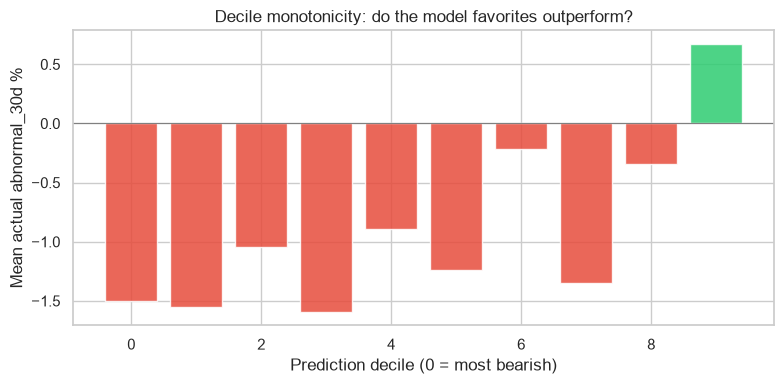

Rank model vs RAW returns : mean IC=+0.0655  t=+2.34  (77% of 31 months positive)


In [7]:
# ==================================================================
# CROSS-SECTIONAL EVALUATION — the metric that matches the trade
# ------------------------------------------------------------------
# RMSE barely moves on noisy returns; what a long/short book actually
# monetizes is the ORDERING of stocks. Views:
#   1. Spearman IC per calendar month (rank corr of pred vs actual)
#      — |mean IC| of 0.02-0.05 with a t-stat > 2 is a usable signal
#   2. Decile spread: mean actual return of top- minus bottom-decile
#   3. Rank-target model: train directly on within-month pct ranks
# When TARGET is the _va variant, predictions are the demeaned/vol-
# adjusted RESIDUAL and are also RECOMBINED with the persistence prior
# (pred_raw = pred_va * va_scale + va_mean); with the raw target the two
# views coincide. IC and decile spread are always reported against RAW
# abnormal returns — that's what a book earns. Untouched EVAL region only.
# ==================================================================
from scipy.stats import spearmanr

if TARGET != TARGET_RAW:
    pred_raw = lgb_p * va_scale[lgb_idx] + va_mean[lgb_idx]   # back to raw % space
else:
    pred_raw = lgb_p
ev = pd.DataFrame({'date': pd.to_datetime(dates[lgb_idx]),
                   'pred': lgb_p,                # model-space predictions
                   'pred_raw': pred_raw,         # raw-space (tradeable) view
                   'actual': y_raw[lgb_idx],     # raw %: what a book earns
                   'actual_model': lgb_a})       # model's own target
ev['period'] = ev['date'].dt.to_period('M')

def ic_report(frame, label):
    ics = (frame.groupby('period')[['pred', 'actual']]
           .apply(lambda g: spearmanr(g['pred'], g['actual'])[0]
                  if len(g) >= 5 else np.nan)
           .dropna())
    mean_ic, std_ic = ics.mean(), ics.std()
    t_stat = mean_ic / std_ic * np.sqrt(len(ics)) if std_ic > 0 else float('nan')
    print(f'{label}: mean IC={mean_ic:+.4f}  t={t_stat:+.2f}  '
          f'({(ics > 0).mean():.0%} of {len(ics)} months positive)')
    return ics

ics_level = ic_report(ev, 'Level model vs RAW returns')
if TARGET != TARGET_RAW:
    _ = ic_report(ev.assign(actual=ev['actual_model']), 'Residual vs own target    ')
    ics_recomb = ic_report(ev.assign(pred=ev['pred_raw']), 'Recombined vs RAW returns ')

# ---- Decile monotonicity (raw returns) ----
for pcol_, lbl in ([('pred', 'model'), ('pred_raw', 'recombined')]
                   if TARGET != TARGET_RAW else [('pred', 'model')]):
    dcl = pd.qcut(ev[pcol_].rank(method='first'), 10, labels=False)
    dm = ev.groupby(dcl)['actual'].mean()
    print(f'Decile spread (D10 − D1), {lbl:10s}: {(dm.iloc[-1]-dm.iloc[0])*1e4:+.0f} bps per event')

ev['decile'] = pd.qcut(ev['pred_raw'].rank(method='first'), 10, labels=False)
dec = ev.groupby('decile')['actual'].agg(['mean', 'count'])
spread_bps = (dec['mean'].iloc[-1] - dec['mean'].iloc[0]) * 1e4

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dec.index, dec['mean'] * 100,
       color=np.where(dec['mean'] >= 0, '#2ecc71', '#e74c3c'), alpha=0.85)
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel('Prediction decile (0 = most bearish)')
ax.set_ylabel(f'Mean actual {TARGET_RAW} %')
ax.set_title('Decile monotonicity: do the model favorites outperform?')
plt.tight_layout(); plt.show()

# ---- Rank-target model ----
# Within-month pct rank of the model target uses only in-month info ex
# post, which is fine for a TARGET (never a feature). winsor=None:
# percentile ranks have no tails to clip. IC still reported vs raw returns.
_period = mdf['matched_earnings_date'].dt.to_period('M')
y_rank = mdf.groupby(_period)[TARGET].rank(pct=True).values
rk_p, rk_a, rk_f, rk_idx = walk_forward_predict(X, y_rank, params=bp, winsor=None)
ev_rk = pd.DataFrame({'date': pd.to_datetime(dates[rk_idx]),
                      'pred': rk_p, 'actual': y_raw[rk_idx]})
ev_rk['period'] = ev_rk['date'].dt.to_period('M')
ics_rank = ic_report(ev_rk, 'Rank model vs RAW returns ')

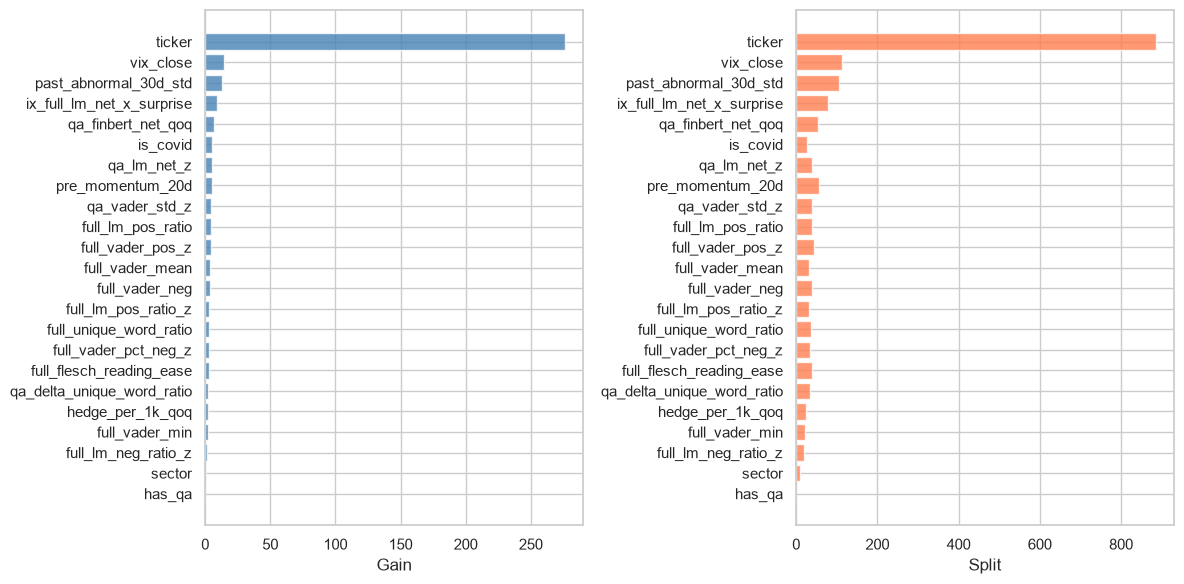

Feature importance:
                   feature       gain  split
                    ticker 276.246248    886
                 vix_close  14.379993    114
     past_abnormal_30d_std  12.786718    106
 ix_full_lm_net_x_surprise   9.194404     79
        qa_finbert_net_qoq   6.823600     54
                  is_covid   5.511567     27
               qa_lm_net_z   5.468647     38
          pre_momentum_20d   5.042535     57
            qa_vader_std_z   4.666923     40
         full_lm_pos_ratio   4.646215     38
          full_vader_pos_z   4.352223     45
           full_vader_mean   3.512299     31
            full_vader_neg   3.504505     38
       full_lm_pos_ratio_z   3.184284     31
    full_unique_word_ratio   3.034916     37
      full_vader_pct_neg_z   2.856290     33
  full_flesch_reading_ease   2.573243     38
qa_delta_unique_word_ratio   2.522883     35
          hedge_per_1k_qoq   2.188260     24
            full_vader_min   1.863234     22
       full_lm_neg_ratio_z   1.7166

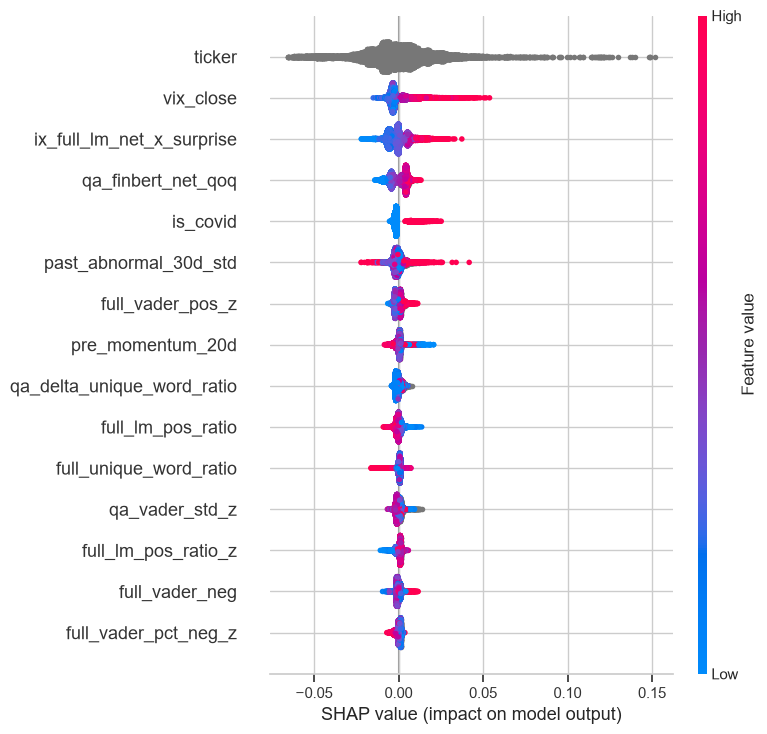

SHAP:
                   feature  mean_abs_shap
                    ticker       0.014226
                 vix_close       0.005164
 ix_full_lm_net_x_surprise       0.004908
        qa_finbert_net_qoq       0.004361
                  is_covid       0.003081
     past_abnormal_30d_std       0.002252
          full_vader_pos_z       0.001692
          pre_momentum_20d       0.001412
qa_delta_unique_word_ratio       0.001346
         full_lm_pos_ratio       0.001301
    full_unique_word_ratio       0.001277
            qa_vader_std_z       0.001223
       full_lm_pos_ratio_z       0.001211
            full_vader_neg       0.001120
      full_vader_pct_neg_z       0.001095
               qa_lm_net_z       0.000840
           full_vader_mean       0.000771
  full_flesch_reading_ease       0.000729
       full_lm_neg_ratio_z       0.000671
          hedge_per_1k_qoq       0.000661
            full_vader_min       0.000600
                    sector       0.000489
                    has_qa  

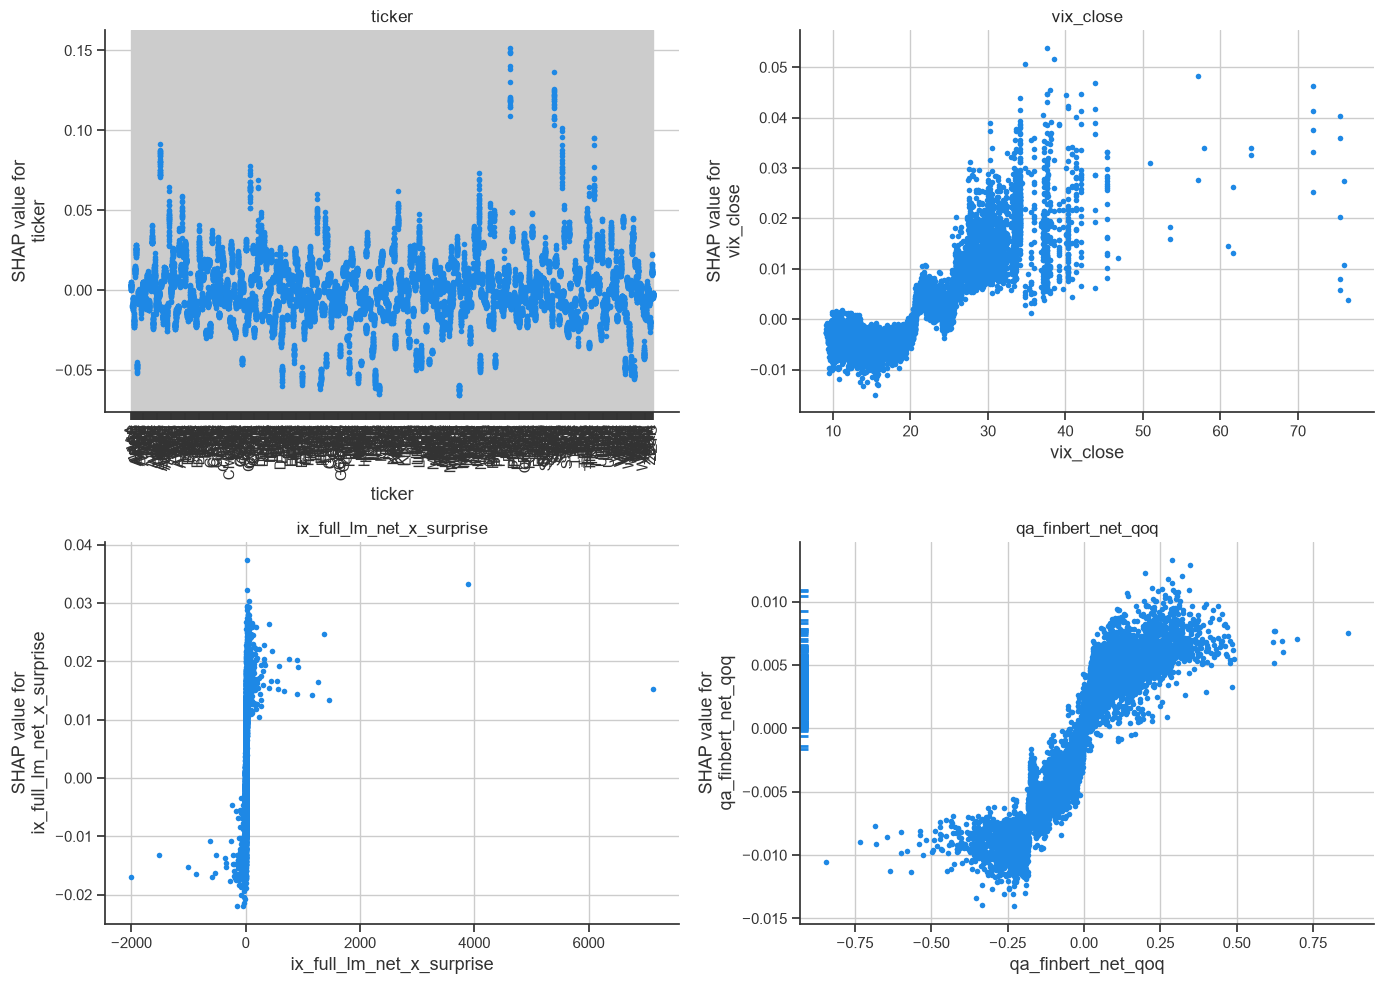

In [8]:
dtrain = lgb.Dataset(X, label=y, categorical_feature=cat_idx if cat_idx else 'auto')
final = lgb.train(bp, dtrain, num_boost_round=300, callbacks=[lgb.log_evaluation(0)])

imp = pd.DataFrame({'feature':final.feature_name(),
    'gain':final.feature_importance('gain'),
    'split':final.feature_importance('split')}).sort_values('gain',ascending=False)
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,6))
a1.barh(imp['feature'][::-1],imp['gain'][::-1],color='steelblue',alpha=0.8)
a1.set_xlabel('Gain')
a2.barh(imp['feature'][::-1],imp['split'][::-1],color='coral',alpha=0.8)
a2.set_xlabel('Split')
plt.tight_layout(); plt.show()
print('Feature importance:'); print(imp.to_string(index=False))

print('\nSHAP...')
ex = shap.TreeExplainer(final)
sv = ex.shap_values(X)
shap.summary_plot(sv, X, feature_names=avail_f, max_display=min(15,len(avail_f)), show=False)
plt.tight_layout(); plt.show()
si = pd.DataFrame({'feature':avail_f,'mean_abs_shap':np.abs(sv).mean(axis=0)}).sort_values('mean_abs_shap',ascending=False)
print('SHAP:'); print(si.to_string(index=False))
fig,axes=plt.subplots(2,2,figsize=(14,10))
for ax,feat in zip(axes.flat,si.head(4)['feature'].tolist()):
    shap.dependence_plot(feat,sv,X,feature_names=avail_f,interaction_index=None,ax=ax,show=False)
    ax.set_title(feat,fontsize=12)
plt.tight_layout(); plt.show()

In [9]:
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
import joblib
joblib.dump(final, MODEL_DIR / f'lgbm_{TARGET}.pkl')
print(f'Saved model')

# Use walk-forward test indices to align prediction arrays with X
preds = X.iloc[lgb_idx].copy()
preds[f'actual_{TARGET}'] = lgb_a
preds[f'predicted_{TARGET}'] = lgb_p
if TARGET != TARGET_RAW:
    # _va target: also persist raw actuals (05 monetizes them) and the
    # recombined raw-space prediction (residual*scale + persistence prior)
    # that 05 prefers for ranking.
    preds[f'actual_{TARGET_RAW}'] = y_raw[lgb_idx]
    preds[f'predicted_{TARGET_RAW}'] = lgb_p * va_scale[lgb_idx] + va_mean[lgb_idx]
preds['residual'] = lgb_a - lgb_p
preds['matched_earnings_date'] = dates[lgb_idx]
preds['walk_forward_fold'] = lgb_f
for i, col in enumerate(avail_f):
    preds[f'shap_{col}'] = sv[lgb_idx, i]

# Dead-zone classifier predictions (NaN where |move| <= DEAD_ZONE sigma)
preds['clf_actual'] = clf_actual_full[lgb_idx]
preds['clf_predicted_prob'] = clf_prob_full[lgb_idx]
preds['clf_predicted_label'] = clf_label_full[lgb_idx]

conn = sqlite3.connect(DB_PATH)
preds.to_sql('model_predictions', conn, if_exists='replace', index=False)
saved = conn.execute("SELECT COUNT(*) FROM model_predictions").fetchone()[0]
conn.close()
print(f'Saved {saved} rows to model_predictions table')

Saved model
Saved 5130 rows to model_predictions table


In [10]:
# ==================================================================
# SECTOR SUB-MODELS — same honest protocol as the global model:
# per group, MI selection + Optuna tuning happen on the first 70%
# of that group's events; performance is reported on the untouched
# last 30% via the shared expanding walk-forward.
# ==================================================================
print('='*65)
print('SECTOR SUB-MODELS')
print('='*65)

SECTOR_GROUPS = {
    'Healthcare_Financials': ['Healthcare','Financials'],
    'Technology': ['Technology'],
    'Rest': None,  # Everything else
}

sub_sectors, sub_rmse, sub_sign, sub_n = [], [], [], []
all_sector_preds = np.full(len(mdf), np.nan)

for gname, sec_list in SECTOR_GROUPS.items():
    print(f'\n{"="*60}')
    print(f'{gname}')
    print(f'{"="*60}')

    if sec_list is None:
        taken = ['Healthcare','Financials','Technology']
        mask = ~mdf['sector'].isin(taken)
    else:
        mask = mdf['sector'].isin(sec_list)
    # IMPORTANT: keep original mdf index for mapping predictions back
    sg_mdf = mdf[mask].copy().sort_values('matched_earnings_date')
    n_rows = len(sg_mdf)
    if n_rows < 100:
        print(f'{gname}: only {n_rows} rows, skipping')
        continue
    print(f'{n_rows} rows, date range {sg_mdf["matched_earnings_date"].min().date()} to {sg_mdf["matched_earnings_date"].max().date()}')

    # Group-specific feature selection — TUNE region of this group only
    tr_cut = int(n_rows*0.70)
    sg_train = sg_mdf.iloc[:tr_cut]
    sg_cand = []
    for c in sg_mdf.columns:
        if c in LEAKY+META+['sector']: continue
        if sg_mdf[c].dtype not in ('float64','int64','bool'): continue
        if sg_mdf[c].notna().sum() < 0.5*n_rows: continue
        sg_cand.append(c)

    if len(sg_cand) < 3:
        print(f'{gname}: only {len(sg_cand)} features, using global features instead')
        sg_cand = [c for c in avail_f if c in sg_mdf.columns and c != 'sector']

    le2 = LabelEncoder()
    ticker_arr = le2.fit_transform(sg_train['ticker'])
    X_arr = np.column_stack([sg_train[sg_cand].fillna(0).values, ticker_arr])
    mi = mutual_info_regression(X_arr, sg_train[TARGET].values, random_state=42)
    mi_sg = pd.DataFrame({'feature':sg_cand+['ticker'],'mi_score':mi}).sort_values('mi_score',ascending=False)
    top_k = int(np.clip(n_rows // 400, 5, 15))
    sg_top = mi_sg.head(top_k)['feature'].tolist()
    if 'ticker' not in sg_top: sg_top.append('ticker')
    sg_avail = [f for f in sg_top if f in sg_mdf.columns]
    print(f'Top features: {sg_avail}')

    X_sg = sg_mdf[sg_avail].copy()
    y_sg = sg_mdf[TARGET].values
    sg_cat = ['ticker'] if 'ticker' in sg_avail else []
    for c in sg_cat:
        X_sg[c] = X_sg[c].astype('category')
    X_sg = X_sg.reset_index(drop=True)   # positional, like the global X

    # Optuna on the group's TUNE region only
    X_sg_tune, y_sg_tune = X_sg.iloc[:tr_cut], y_sg[:tr_cut]
    cat_ix = [i for i,c in enumerate(X_sg.columns) if c in sg_cat]
    nf_tune = min(5, max(2, tr_cut//60))
    tscv_sg = TimeSeriesSplit(n_splits=nf_tune)

    def obj_sg(trial):
        ps = {'objective':'regression','metric':'rmse','boosting_type':'gbdt',
            'num_leaves':trial.suggest_int('num_leaves',4,8),
            'learning_rate':trial.suggest_float('lr',0.01,0.08,log=True),
            'feature_fraction':trial.suggest_float('ff',0.5,0.8),
            'bagging_fraction':trial.suggest_float('bf',0.5,0.8),
            'bagging_freq':trial.suggest_int('b_freq',1,7),
            'min_data_in_leaf':trial.suggest_int('mdl',10,60),
            'lambda_l1':trial.suggest_float('l1',0.5,10.0,log=True),
            'lambda_l2':trial.suggest_float('l2',0.5,10.0,log=True),
            'verbose':-1,'random_state':42,'num_threads':4}
        sc_ = []
        for tr, vl in tscv_sg.split(X_sg_tune):
            dt = lgb.Dataset(X_sg_tune.iloc[tr], label=y_sg_tune[tr], categorical_feature=cat_ix if cat_ix else 'auto')
            dv = lgb.Dataset(X_sg_tune.iloc[vl], label=y_sg_tune[vl], reference=dt, categorical_feature=cat_ix if cat_ix else 'auto')
            m = lgb.train(ps, dt, num_boost_round=200, valid_sets=[dv],
                callbacks=[lgb.early_stopping(15),lgb.log_evaluation(0)])
            sc_.append(np.sqrt(mean_squared_error(y_sg_tune[vl], m.predict(X_sg_tune.iloc[vl]))))
        return np.mean(sc_)

    nt = min(20, max(10, n_rows//15))
    so = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    so.optimize(obj_sg, n_trials=nt, show_progress_bar=False)
    print(f'Best tune-CV RMSE: {so.best_value:.6f}')

    bp_sg = so.best_params.copy()
    bp_sg = {'objective':'regression','metric':'rmse','boosting_type':'gbdt',
             'num_leaves':bp_sg.get('num_leaves',6),'learning_rate':bp_sg.get('lr',0.05),
             'feature_fraction':bp_sg.get('ff',0.7),'bagging_fraction':bp_sg.get('bf',0.7),
             'bagging_freq':bp_sg.get('b_freq',5),'min_data_in_leaf':bp_sg.get('mdl',15),
             'lambda_l1':bp_sg.get('l1',1.0),'lambda_l2':bp_sg.get('l2',1.0),
             'verbose':-1,'random_state':42}
    # Shared expanding walk-forward over the group's untouched eval tail
    p, a, _, ix = walk_forward_predict(X_sg, y_sg, params=bp_sg,
                                       start=tr_cut,
                                       n_folds=min(3, max(2, (n_rows - tr_cut)//60)),
                                       cat_cols=sg_cat)

    rmse_sg = np.sqrt(mean_squared_error(a, p))
    base_sg = np.sqrt(mean_squared_error(a, [y_sg[:tr_cut].mean()]*len(a)))
    sign_sg = np.sum(np.sign(p)==np.sign(a))/len(a)*100
    corr_sg = np.corrcoef(p,a)[0,1]
    print(f'Baseline: {base_sg:.4f}  LGBM: {rmse_sg:.4f}  Imp: {(base_sg-rmse_sg)/base_sg*100:+.1f}%')
    print(f'Sign accuracy: {sign_sg:.1f}%  Corr: {corr_sg:.3f}')

    # ix are positions in X_sg == positions in sg_mdf -> original mdf index
    for i, pos in enumerate(ix):
        all_sector_preds[sg_mdf.index[pos]] = p[i]
    sub_sectors.append(gname); sub_rmse.append(rmse_sg)
    sub_sign.append(sign_sg); sub_n.append(n_rows)

# ---- Combined metrics (each group's eval tail; ~last 30% overall) ----
print(f'\n{"="*65}')
print('COMBINED SECTOR SUB-MODEL PERFORMANCE')
print(f'{"="*65}')
valid_mask = ~np.isnan(all_sector_preds)
if valid_mask.sum() > 0:
    comb_p = all_sector_preds[valid_mask]
    comb_act = mdf[TARGET].values[valid_mask]
    comb_rmse = np.sqrt(mean_squared_error(comb_act, comb_p))
    comb_sign = np.sum(np.sign(comb_p)==np.sign(comb_act))/len(comb_p)*100
    comb_r2 = r2_score(comb_act, comb_p)
    print(f'Combined sub-models: RMSE={comb_rmse:.6f}  Sign={comb_sign:.1f}%  R^2={comb_r2:.4f}')
    print(f'Global single model: RMSE={lgb_rmse:.6f}  Sign={sign:.1f}%  R^2={r2_score(lgb_a,lgb_p):.4f}')
    print(f'Improvement: RMSE {(lgb_rmse-comb_rmse)/lgb_rmse*100:+.1f}%  Sign {(comb_sign-sign):+.1f}pp')

    print(f'\n{"="*65}')
    print('PER-GROUP SUMMARY')
    print(f'{"="*65}')
    sg_summary = pd.DataFrame({'group':sub_sectors,'n':sub_n,'rmse':sub_rmse,'sign':sub_sign})
    print(sg_summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
else:
    print('No sector group had enough rows.')

SECTOR SUB-MODELS

Healthcare_Financials
288 rows, date range 2016-07-14 to 2025-04-29
Top features: ['full_vader_std', 'pre_momentum_20d', 'vix_close', 'qa_finbert_net_qoq', 'va_scale', 'ticker']
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0574594
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[5]	valid_0's rmse: 0.101317
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.073005
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0574594
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.101366
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0729963
Training until validation scores don't improve for

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0574594
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.101366
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0729759
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0574594
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.101366
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0729759
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0574594
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.10

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0574594
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.101366
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0729759
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0574594
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.101366
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0729759
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0574594
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.10

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.101366
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0729759
Best tune-CV RMSE: 0.077267
Baseline: 0.0960  LGBM: 0.0960  Imp: -0.0%
Sign accuracy: 41.4%  Corr: -0.103

Technology
510 rows, date range 2016-07-18 to 2025-05-14
Top features: ['ticker', 'full_lm_pos_ratio', 'full_lm_neg_ratio', 'full_lm_net', 'qa_delta_vader_mean']


Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[59]	valid_0's rmse: 0.155556
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.109964
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[8]	valid_0's rmse: 0.112449
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[76]	valid_0's rmse: 0.100048
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.122461
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[86]	valid_0's rmse: 0.155705
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.109839
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[36]	valid_0's rmse: 0.111

...

Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[31]	valid_0's rmse: 0.0969342
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.0788146
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[34]	valid_0's rmse: 0.0817226
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[20]	valid_0's rmse: 0.13257
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[91]	valid_0's rmse: 0.100276
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[70]	valid_0's rmse: 0.0968128
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[12]	valid_0's rmse: 0.0787966
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[125]	valid_0's rms

Early stopping, best iteration is:
[1]	valid_0's rmse: 0.132582
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[14]	valid_0's rmse: 0.100862
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[17]	valid_0's rmse: 0.0970391
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[34]	valid_0's rmse: 0.0788127
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[172]	valid_0's rmse: 0.0815215
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[21]	valid_0's rmse: 0.132563
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[86]	valid_0's rmse: 0.100206
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[25]	valid_0's rmse: 0.0968793
Training until validation scores don't improve fo

Did not meet early stopping. Best iteration is:
[189]	valid_0's rmse: 0.0815609
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[31]	valid_0's rmse: 0.132504
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[38]	valid_0's rmse: 0.100361
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[25]	valid_0's rmse: 0.0969
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[38]	valid_0's rmse: 0.0787968
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[104]	valid_0's rmse: 0.0813179
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[9]	valid_0's rmse: 0.132537
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[54]	valid_0's rmse: 0.10049
Training until validation scores don't 

Early stopping, best iteration is:
[26]	valid_0's rmse: 0.0969183
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[9]	valid_0's rmse: 0.0788172
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[60]	valid_0's rmse: 0.0812561
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[3]	valid_0's rmse: 0.132595
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[107]	valid_0's rmse: 0.0996688
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[6]	valid_0's rmse: 0.0967989
Best tune-CV RMSE: 0.097827


Baseline: 0.1043  LGBM: 0.1045  Imp: -0.2%
Sign accuracy: 50.5%  Corr: 0.059

COMBINED SECTOR SUB-MODEL PERFORMANCE
Combined sub-models: RMSE=0.105424  Sign=50.5%  R^2=-0.0215
Global single model: RMSE=0.105277  Sign=52.3%  R^2=-0.0183
Improvement: RMSE -0.1%  Sign -1.8pp

PER-GROUP SUMMARY
                group     n   rmse    sign
Healthcare_Financials   288 0.0960 41.3793
           Technology   510 0.1348 55.5556
                 Rest 16300 0.1045 50.5317


In [11]:
# ==================================================================
# LLM FEATURE A/B — runs only once the pilot has scored enough tickers
# ------------------------------------------------------------------
# Protocol (docs/llm_qa_plan.md §4): restrict to tickers whose calls
# are mostly covered by llm_qa_scores (the pilot scores COMPLETE
# tickers so QoQ/expanding features stay valid), then run the same
# MI-selection + walk-forward protocol twice — WITHOUT and WITH llm_*
# candidates — using the main model's tuned params for both arms
# (identical treatment; the only difference is the candidate set).
# GATE: mean monthly IC improves by >= +0.010, or llm features enter
# arm B's selection with economically sensible signs. Otherwise the
# LLM features don't earn a place and scoring the full corpus is off.
# ==================================================================
LLM_MIN_TICKERS = 20
LLM_GATE_IC = 0.010

llm_feats = sorted(c for c in df.columns if c.startswith('llm_'))
if not llm_feats:
    print('LLM A/B: skipped — no llm_* columns (llm_qa_scores empty).')
else:
    _has = df[llm_feats[0]].notna()
    _cov_by_tk = _has.groupby(df['ticker']).mean()
    ab_tickers = set(_cov_by_tk[_cov_by_tk >= 0.6].index)
    if len(ab_tickers) < LLM_MIN_TICKERS:
        print(f'LLM A/B: skipped — only {len(ab_tickers)} ticker(s) with >=60% '
              f'coverage (need >= {LLM_MIN_TICKERS}). Run the pilot: '
              f'scripts/run_llm_extraction.py --pilot 65')
    else:
        sub = (df[df['ticker'].isin(ab_tickers)]
               .dropna(subset=[TARGET])
               .sort_values('matched_earnings_date').reset_index(drop=True))
        y_ab = sub[TARGET].values
        y_ab_raw = sub[TARGET_RAW].values
        print(f'LLM A/B universe: {len(ab_tickers)} tickers, {len(sub):,} events, '
              f'{sub["matched_earnings_date"].min().date()} -> '
              f'{sub["matched_earnings_date"].max().date()}')

        def run_arm(extra_cands, label):
            cands = [c for c in cand if c in sub.columns] + list(extra_cands)
            cut = int(len(sub) * TUNE_FRAC)
            tr = sub.iloc[:cut]
            mi_vals = mutual_info_regression(
                np.column_stack([tr[cands].fillna(0).values,
                                 LabelEncoder().fit_transform(tr['ticker'])]),
                tr[TARGET].values, random_state=42)
            mi_rank = (pd.DataFrame({'feature': cands + ['ticker'], 'mi': mi_vals})
                       .sort_values('mi', ascending=False))
            k = int(np.clip(len(sub) // 400, 8, 20))
            feats = mi_rank.head(k)['feature'].tolist()
            for extra in ['ticker', 'sector', 'has_qa']:
                if extra not in feats and extra in sub.columns:
                    feats.append(extra)
            feats = [c for c in feats if c in sub.columns]
            X_ab = sub[feats].copy()
            for c in CAT_FEATS:
                if c in X_ab.columns:
                    X_ab[c] = X_ab[c].astype('category')
            p, _act, _fld, ix = walk_forward_predict(X_ab, y_ab, params=bp)
            ev_ab = pd.DataFrame(
                {'date': pd.to_datetime(sub['matched_earnings_date'].values[ix]),
                 'pred': p, 'actual': y_ab_raw[ix]})
            ev_ab['period'] = ev_ab['date'].dt.to_period('M')
            ics = ic_report(ev_ab, label)
            dcl = pd.qcut(ev_ab['pred'].rank(method='first'), 10, labels=False)
            dm = ev_ab.groupby(dcl)['actual'].mean()
            spread = (dm.iloc[-1] - dm.iloc[0]) * 1e4
            llm_sel = [c for c in feats if c.startswith('llm_')]
            print(f'  spread {spread:+.0f} bps | {len(feats)} feats'
                  + (f' | llm selected: {llm_sel}' if llm_sel else
                     (' | NO llm features survived MI selection'
                      if extra_cands else '')))
            return ics, spread

        ics_a, spread_a = run_arm([], 'Arm A (no LLM)  ')
        ics_b, spread_b = run_arm(llm_feats, 'Arm B (with LLM)')

        both = pd.concat([ics_a.rename('a'), ics_b.rename('b')], axis=1).dropna()
        d_ic = both['b'].mean() - both['a'].mean()
        diff = both['b'] - both['a']
        t_d = (diff.mean() / diff.std() * np.sqrt(len(diff))
               if diff.std() > 0 else float('nan'))
        print(f'\nDelta mean IC (B - A): {d_ic:+.4f}  '
              f'(paired monthly t={t_d:+.2f})  '
              f'| delta spread: {spread_b - spread_a:+.0f} bps')
        print('GATE:', 'PASS — LLM features earn a place; consider scoring the full corpus.'
              if d_ic >= LLM_GATE_IC else
              'FAIL — LLM features do not add IC on the pilot universe.')

LLM A/B: skipped — only 0 ticker(s) with >=60% coverage (need >= 20). Run the pilot: scripts/run_llm_extraction.py --pilot 65
